In [5]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps 0 to 140
res='1km';t_res='5min'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [6]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [9]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

Minimum Cloudbase is: 1.2463867664337158



In [ ]:
#############################################

currently on type all
currently on type shallow
currently on type deep
(-5.7413934082052736, 9.169738473047236)
(-0.7796000954695046, 17.05360203469172)
(-0.3008802050414185, 0.2515942747704685)
(-0.7796000954695046, 17.05360203469172)


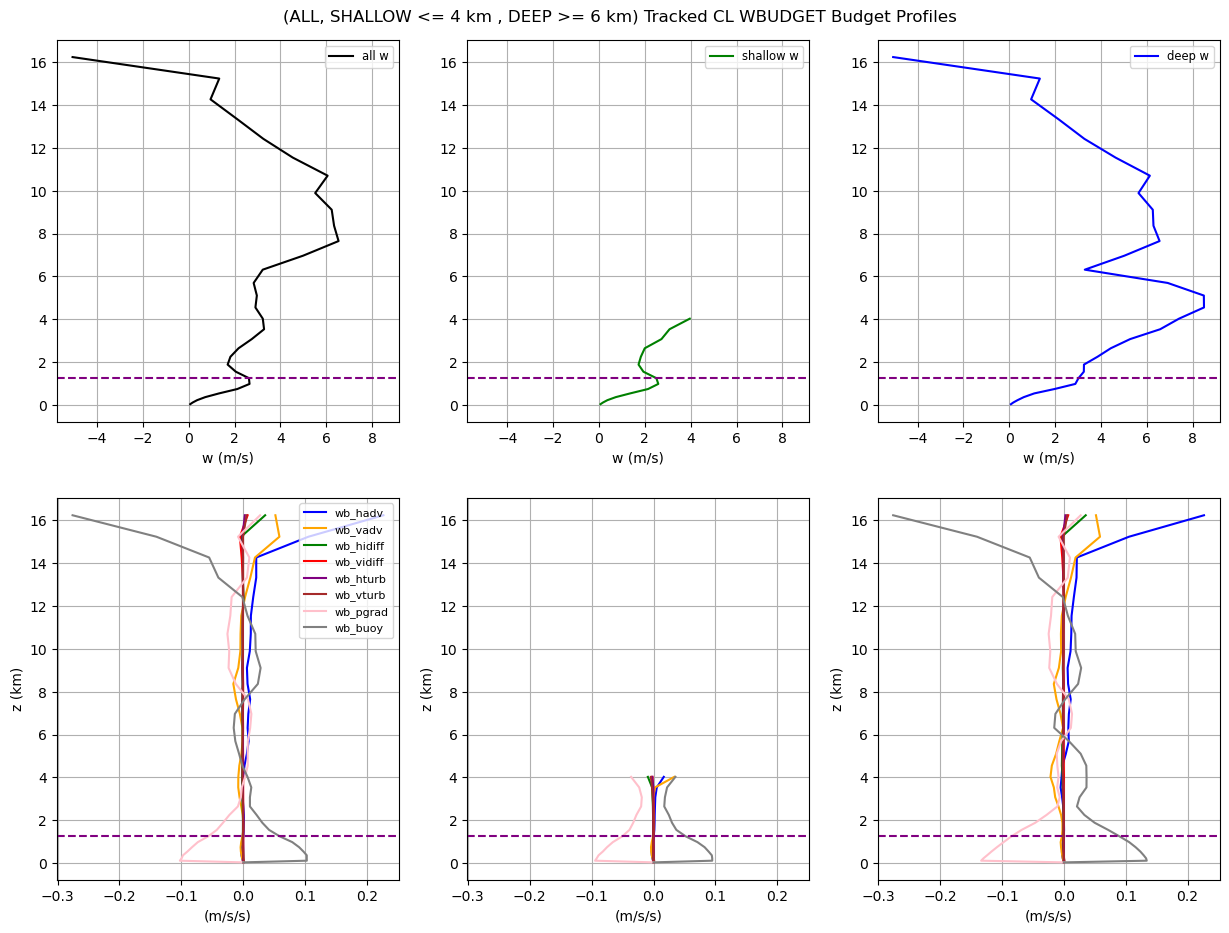

In [10]:
#CL W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked CL WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_WBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow': 
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_WBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':  
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_WBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        
    if type=='all':        
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.7589335444591395, 16.000084355649626)
(-0.7796000954695046, 17.05360203469172)
(-0.017683031928545496, 0.021135458337084856)
(-0.7796000954695046, 17.05360203469172)


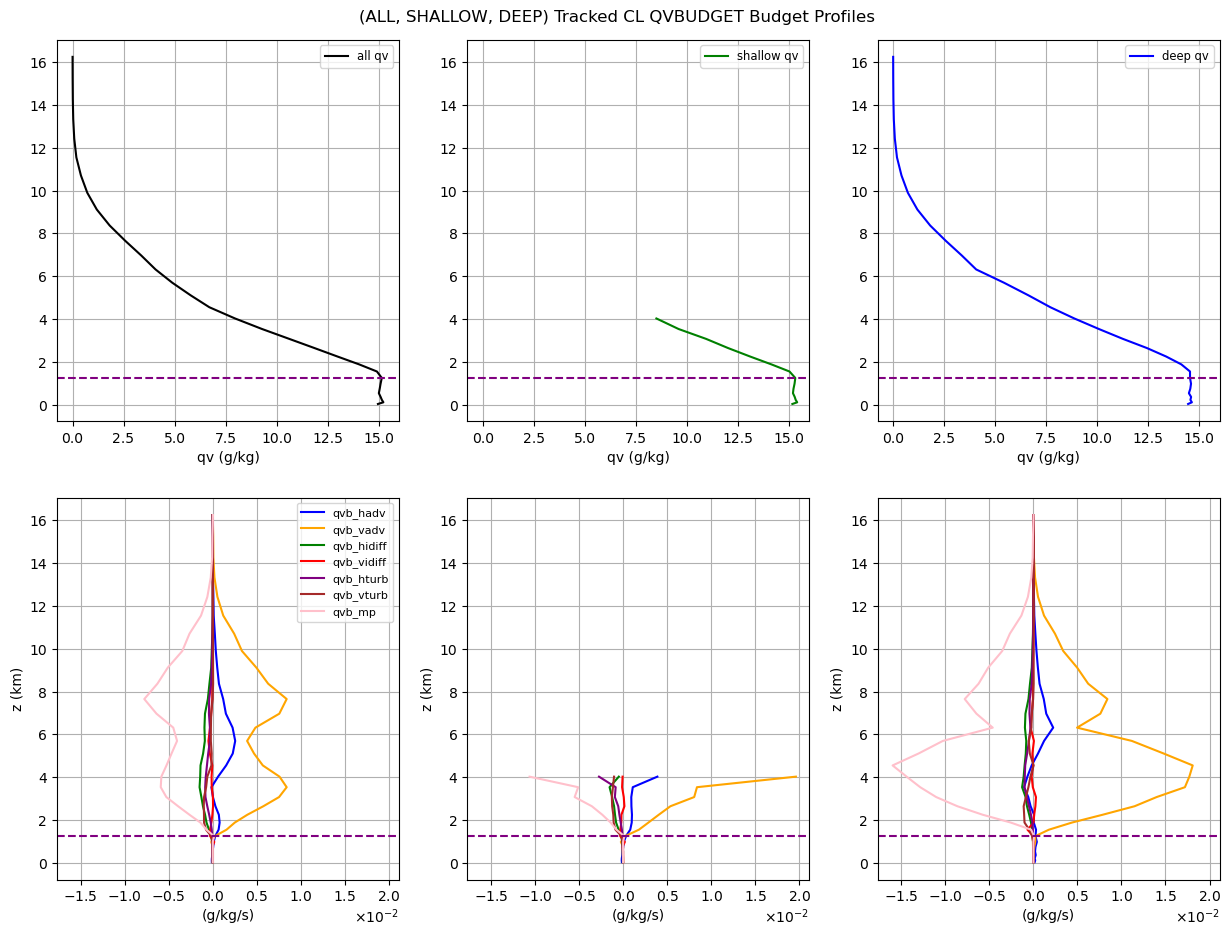

In [11]:
#QV BUDGETS



import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL QVBUDGET Budget Profiles ")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_QVBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_QVBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_QVBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0]*1000,out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend


#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CL_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(302.3904958242661, 372.32596973164453)
(-0.7796000954695046, 17.05360203469172)
(-0.16787707585220538, 0.15945710704351465)
(-0.7796000954695046, 17.05360203469172)


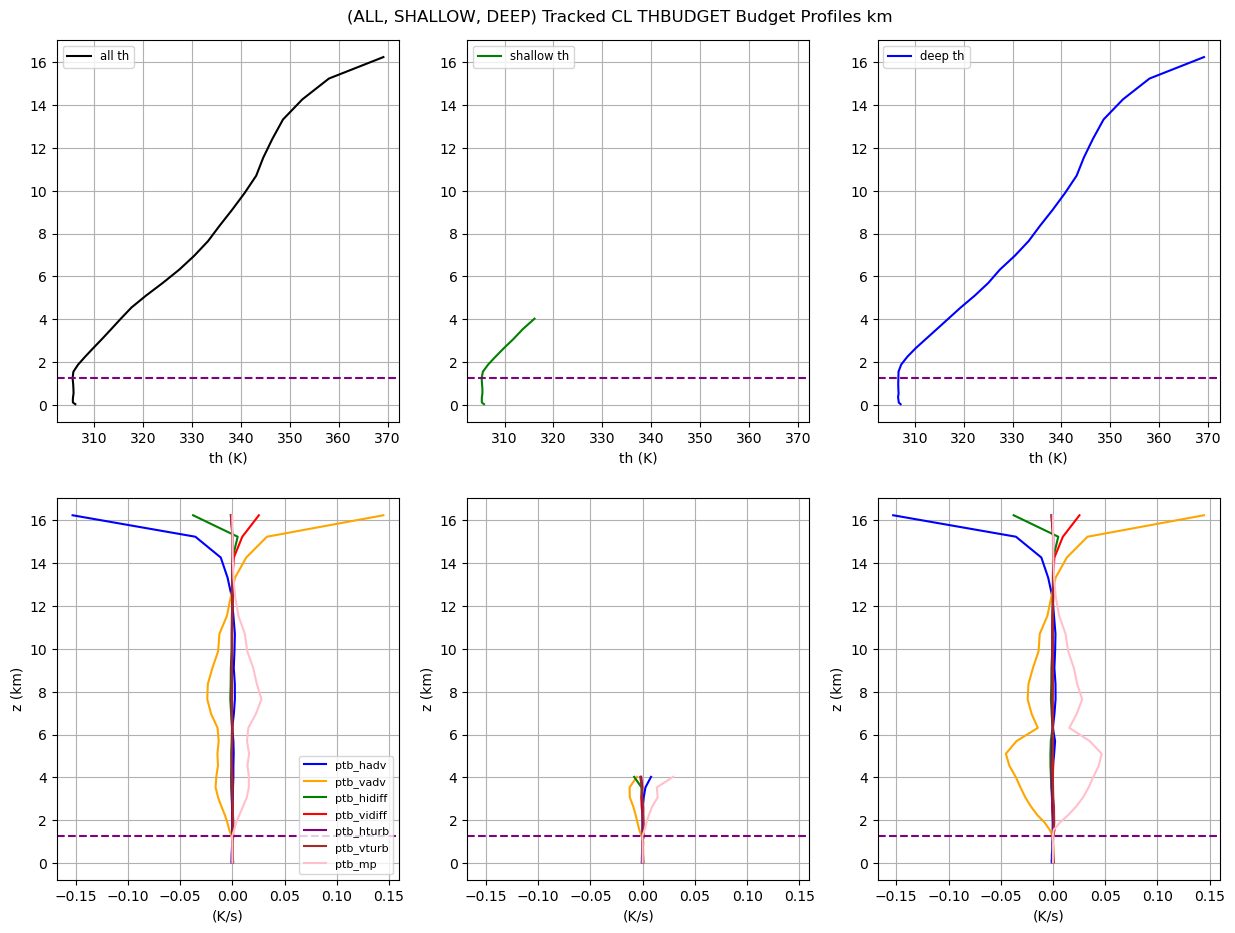

In [13]:
#TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL THBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_THBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_THBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_THBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower right', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CL_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-3.3024909306296477, 9.948452216715042)
(-0.8313374039717019, 18.140085513237864)
(-0.7468329414725303, 0.42375547140836717)
(-0.8313374039717019, 18.140085513237864)


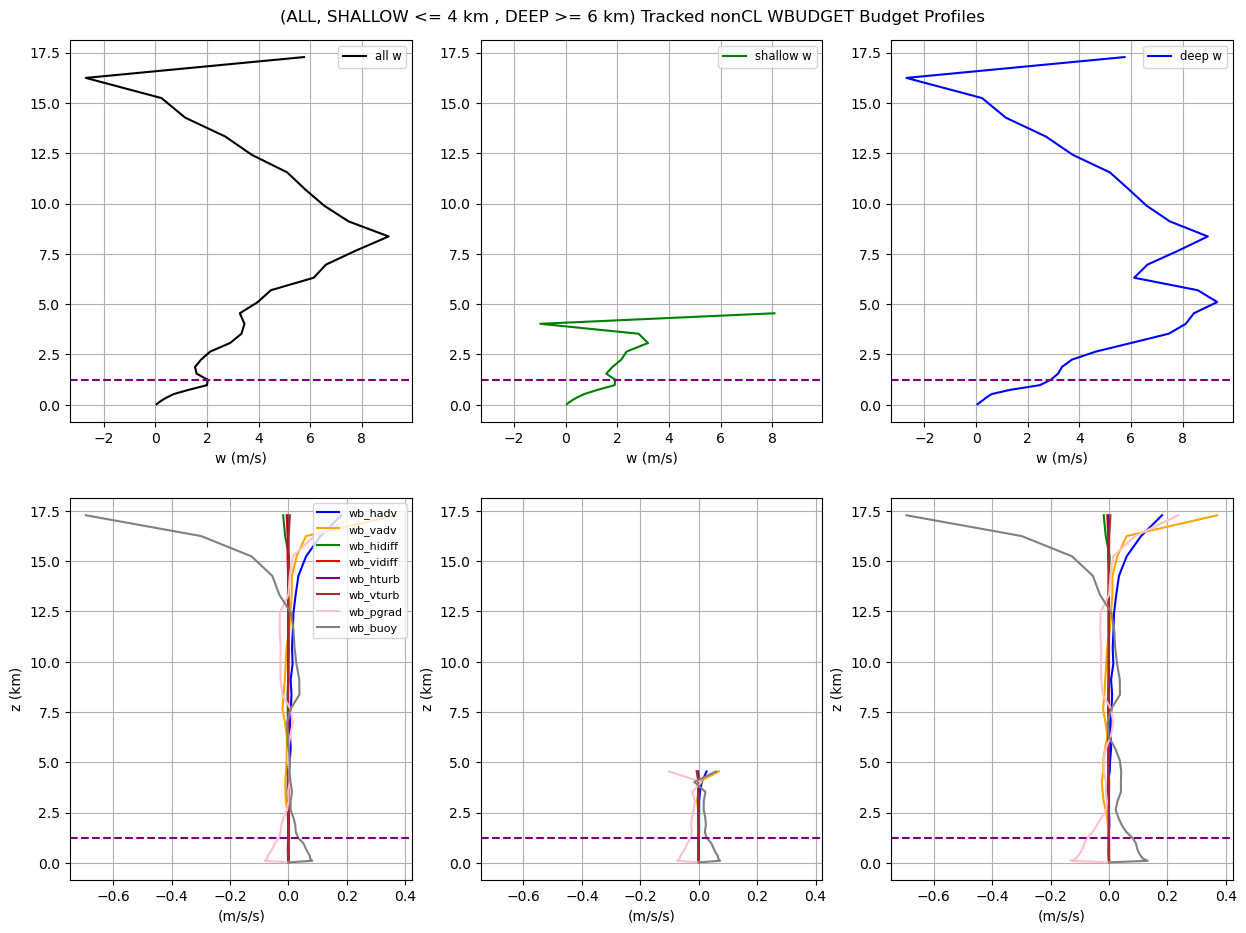

In [14]:
#nonCL W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked nonCL WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_WBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow': 
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_WBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':  
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_WBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_save_nz),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_save_nz),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_save_nz),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonCL_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.7976203347017213, 16.774834307541532)
(-0.8313374039717019, 18.140085513237864)
(-0.019182396044925554, 0.02683214324861183)
(-0.8313374039717019, 18.140085513237864)


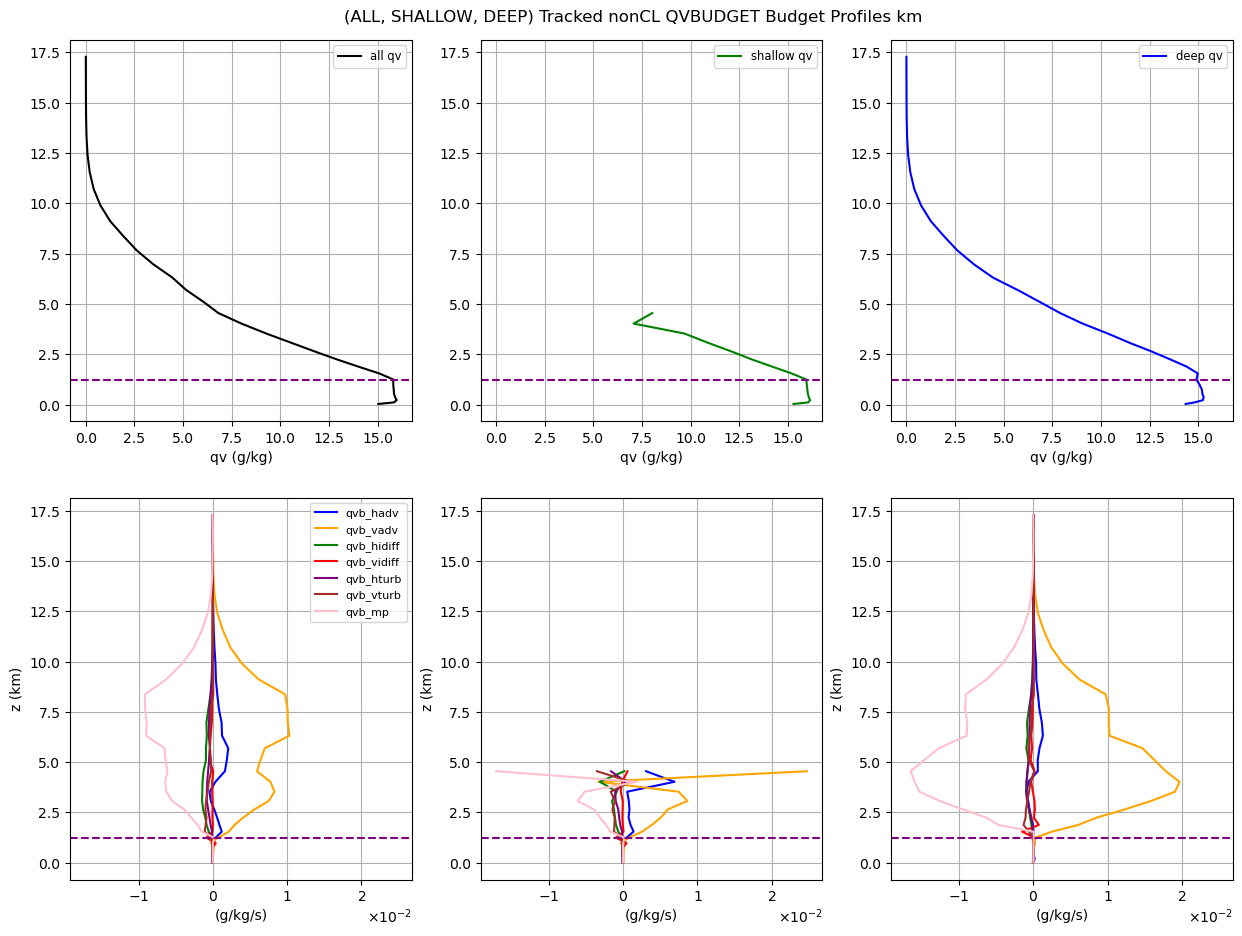

In [15]:
#nonCL QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonCL QVBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_QVBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_QVBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_QVBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0]*1000,out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_save_nz),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_save_nz),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_save_nz),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonCL_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(301.23330565735995, 375.1470381095082)
(-0.8313374039717019, 18.140085513237864)
(-0.12993276845663787, 0.12198952194303274)
(-0.8313374039717019, 18.140085513237864)


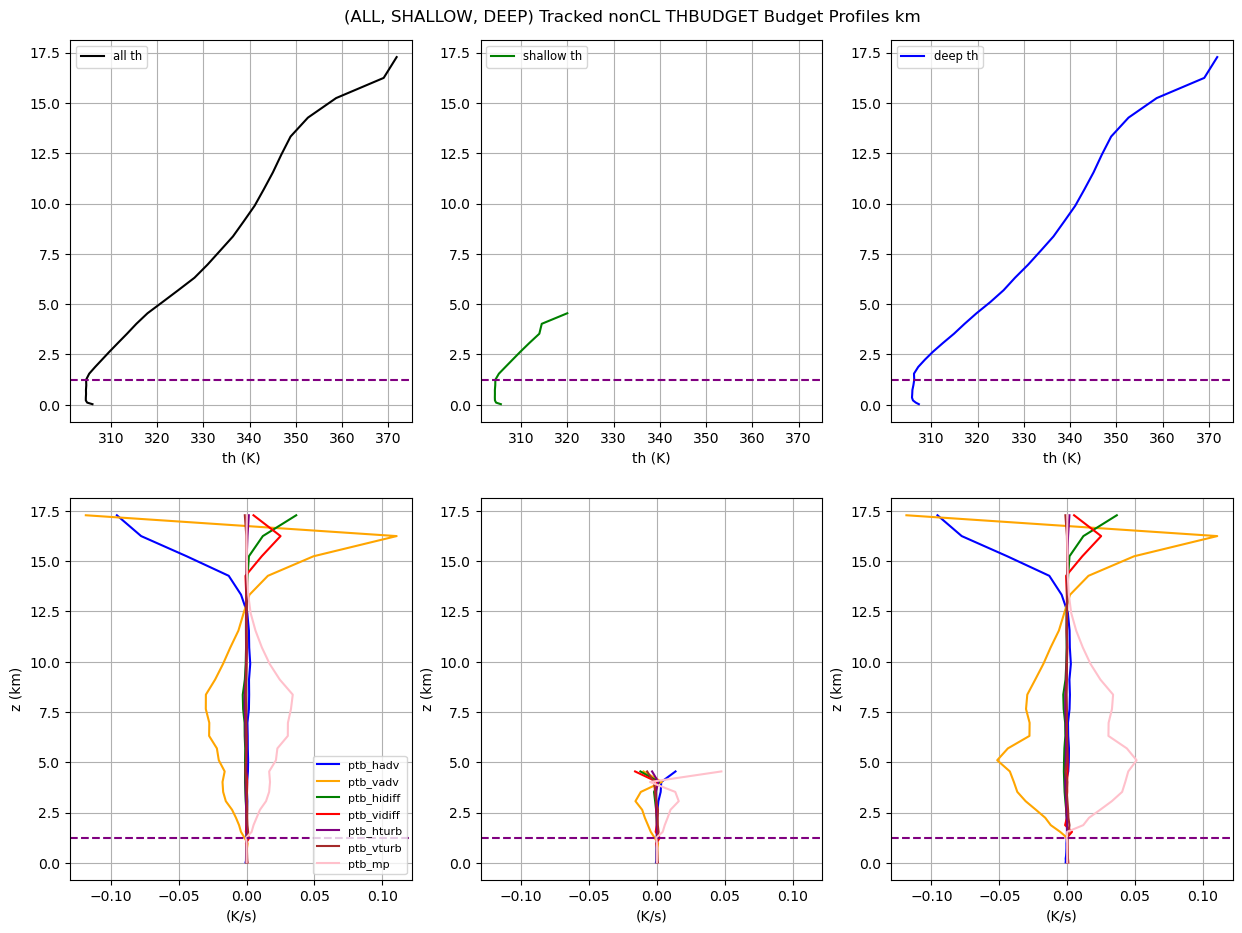

In [16]:
#nonCL TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonCL THBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_THBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_THBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_THBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower right', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_save_nz),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_save_nz),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_save_nz),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonCL_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [ ]:
#CL minus nonCL

In [17]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

currently on type all
currently on type shallow
currently on type deep
(-3.101918991113564, 5.22305869491938)
(-0.7796000954695046, 17.05360203469172)
(-0.07092428722108404, 0.1257439497175316)
(-0.7796000954695046, 17.05360203469172)


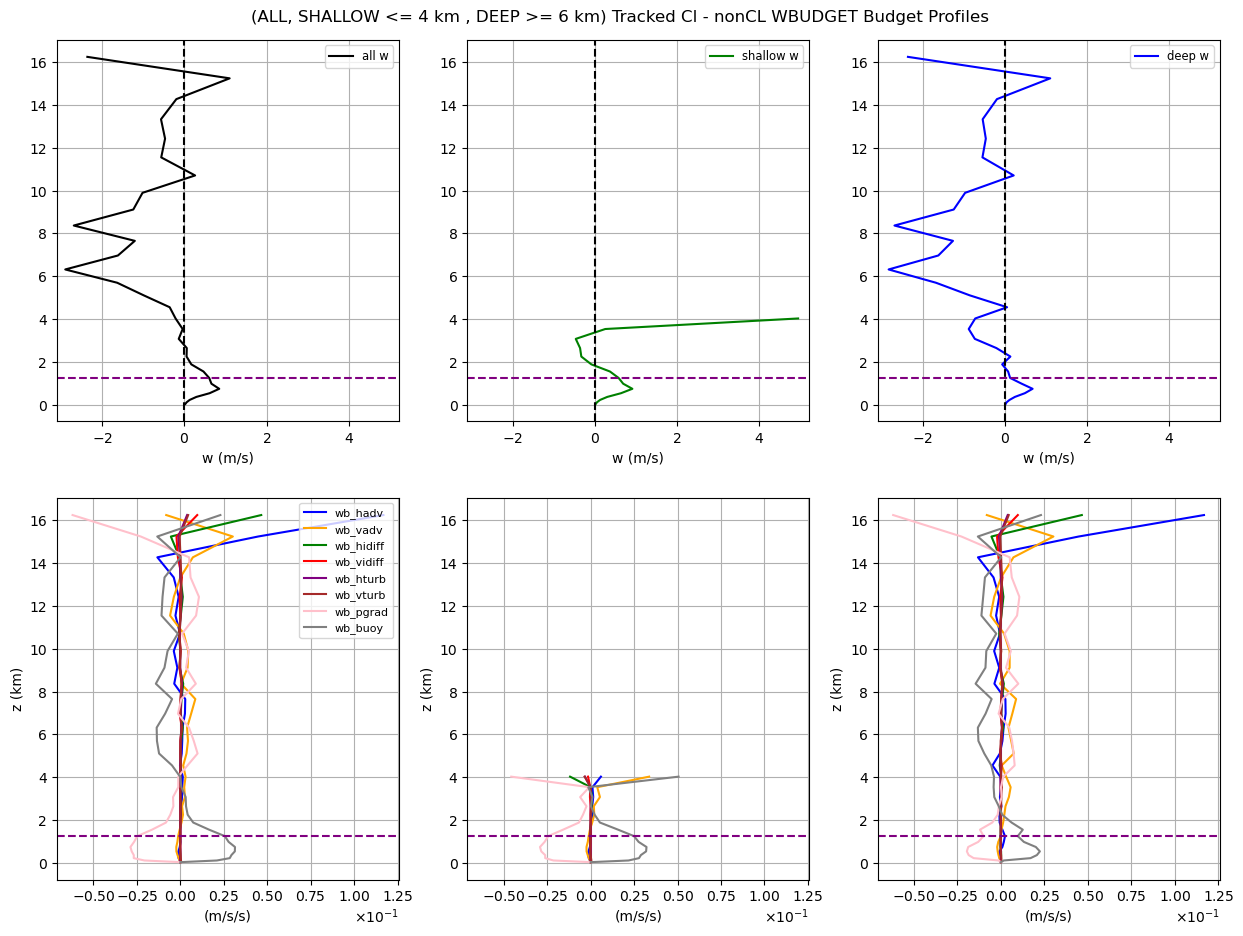

In [19]:
#CL-nonCL W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked Cl - nonCL WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

    if type=='all':    
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_WBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow': 
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_WBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':  
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_WBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w1 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv1 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv1 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff1 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff1 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb1 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb1 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad1 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy1 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy
    
    if type=='all':    
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_WBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow': 
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_WBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':  
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_WBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w2 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv2 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv2 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff2 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff2 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb2 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb2 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad2 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy2 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

    
#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3,ax4,ax5,ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_arr), mean_LFC(ALL_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_out_arr), mean_LFC(SHALLOW_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_out_arr), mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CLminusnonCL_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.000932950487459096, 0.0015546111814902128)
(-0.7796000954695046, 17.05360203469172)
(-1.4234458382844651e-05, 2.4729298494463593e-05)
(-0.7796000954695046, 17.05360203469172)


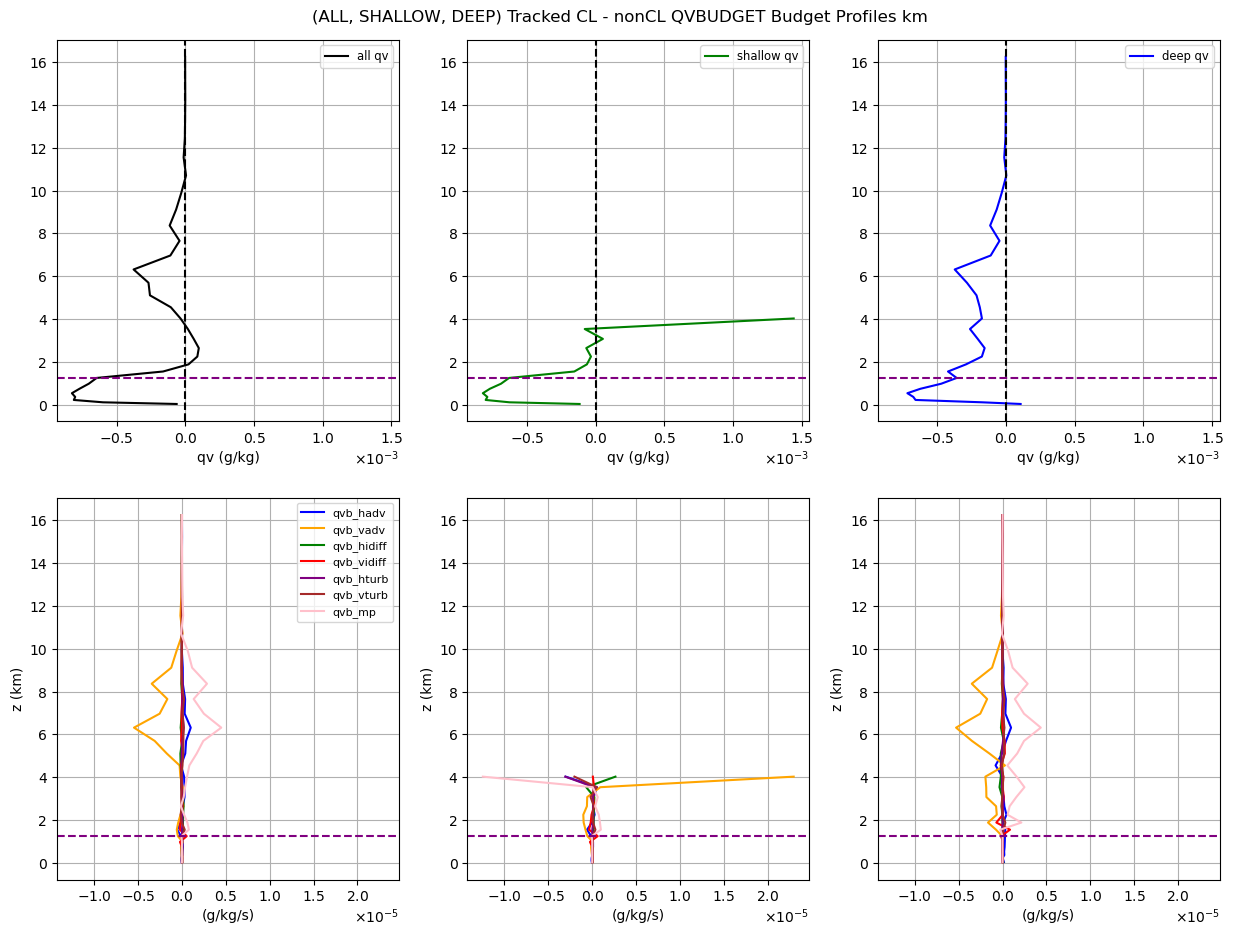

In [20]:
#CL - nonCL QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL - nonCL QVBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

     
    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_QVBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_QVBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_QVBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv1 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv1 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv1 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff1 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff1 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb1 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb1 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp1 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_QVBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_QVBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_QVBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv2 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv2 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv2 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff2 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff2 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb2 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb2 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp2 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_arr), mean_LFC(ALL_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_out_arr), mean_LFC(SHALLOW_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_out_arr), mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

    
#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/ClminusnonCL_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-0.8549425831424629, 1.7694775973611883)
(-0.7796000954695046, 17.05360203469172)
(-0.08073102183019122, 0.039505047692606834)
(-0.7796000954695046, 17.05360203469172)


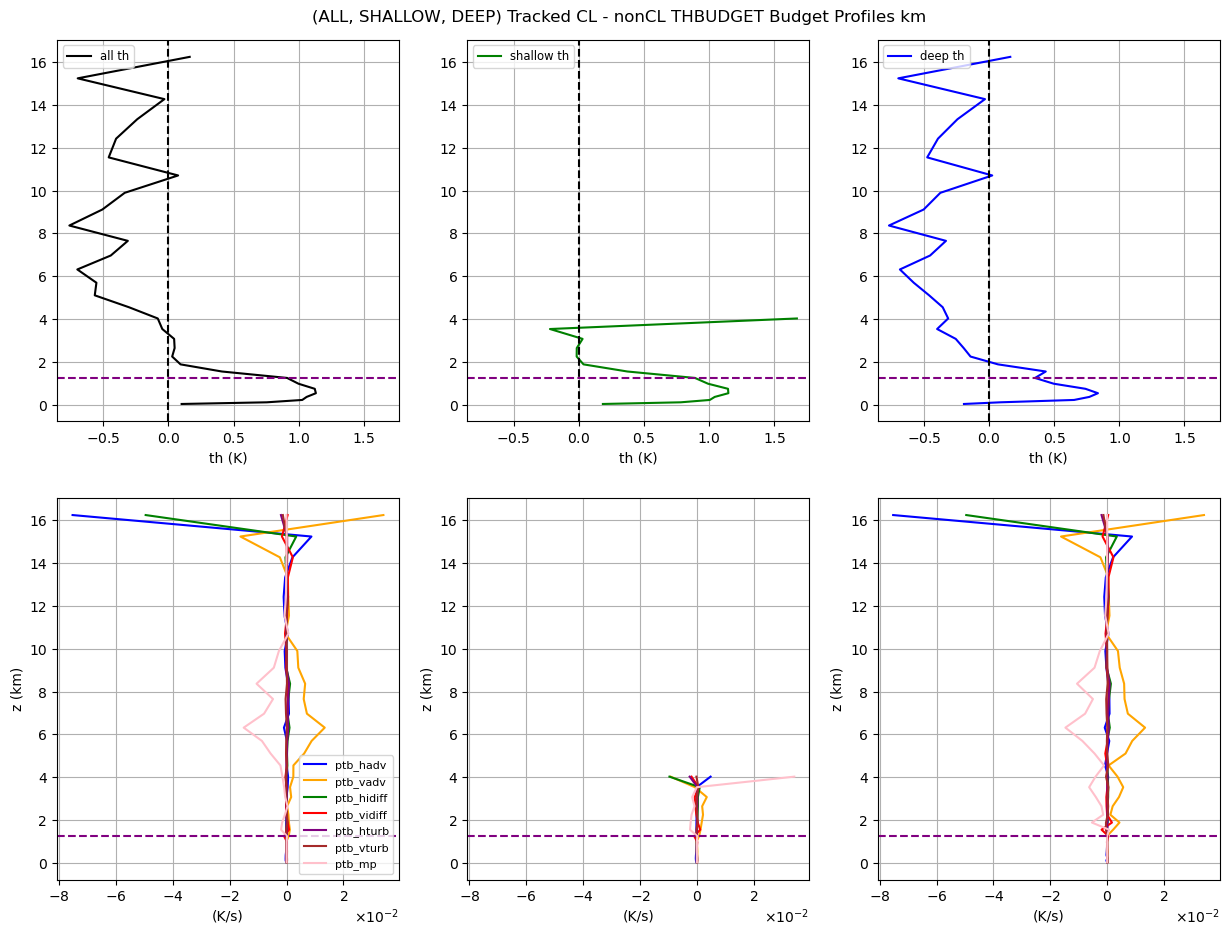

In [23]:
#CL - nonCL TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL - nonCL THBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')


    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_THBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_THBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_THBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th1 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv1 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv1 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff1 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff1 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb1 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb1 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp1 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient

    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_THBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_THBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_THBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'

    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th2 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv2 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv2 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff2 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff2 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb2 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb2 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp2 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower right', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_arr), mean_LFC(ALL_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_out_arr), mean_LFC(SHALLOW_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_out_arr), mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3,ax4,ax5,ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CLminusnonCL_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [22]:
#SBZ vs NONSBZ
################################################################

currently on type all
currently on type shallow
currently on type deep
(-2.6496401113707844, 9.651281111560216)
(-0.6809093949384988, 14.981097323540599)
(-0.11618886413176305, 0.09377163548756028)
(-0.6809093949384988, 14.981097323540599)


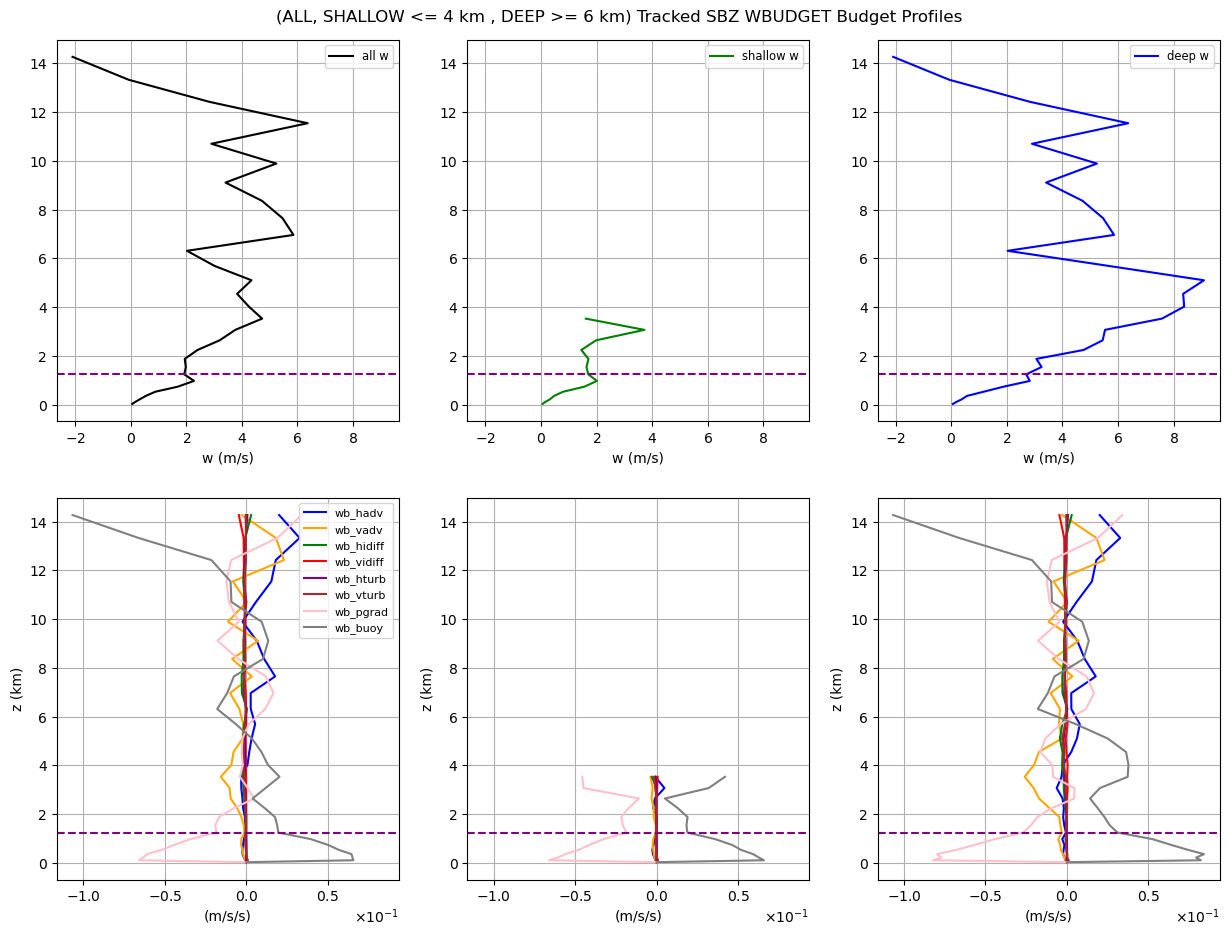

In [24]:
#SBZ W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked SBZ WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_WBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow': 
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_WBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':  
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_WBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_SBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZ_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.8035045182690252, 17.10413771384472)
(-0.6809093949384988, 14.981097323540599)
(-0.017917440904618706, 0.02188828199363519)
(-0.6809093949384988, 14.981097323540599)


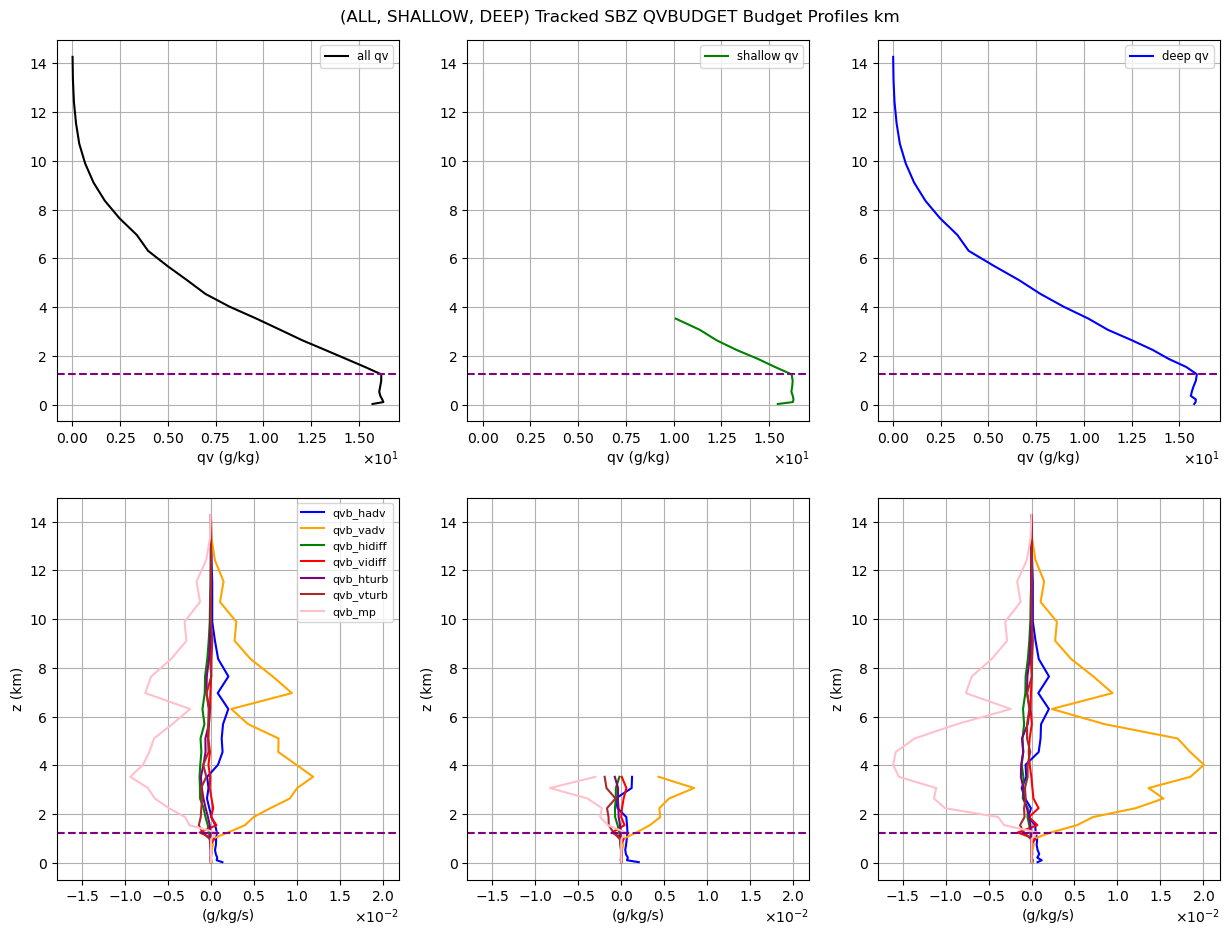

In [25]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ QVBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_QVBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_QVBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_QVBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0]*1000,out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
    
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_SBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZ_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(301.8835629878153, 352.9040751255802)
(-0.6809093949384988, 14.981097323540599)
(-0.04990303775880531, 0.05468024792711863)
(-0.6809093949384988, 14.981097323540599)


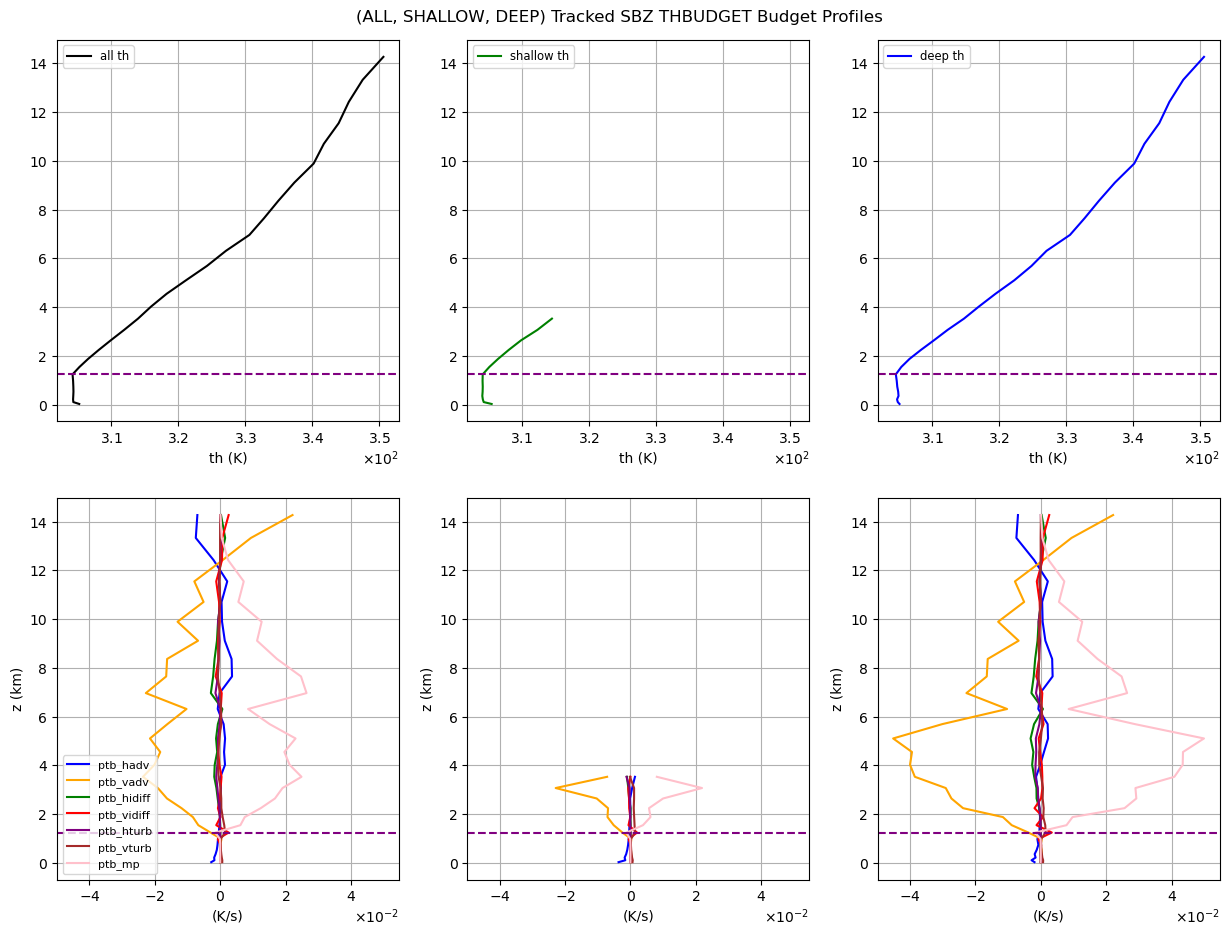

In [26]:
#TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ THBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_THBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_THBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_THBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
    
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower left', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_SBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZ_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-5.74257168069052, 9.194482195237413)
(-0.7796000954695046, 17.05360203469172)
(-0.3008802050414185, 0.2515942747704685)
(-0.7796000954695046, 17.05360203469172)


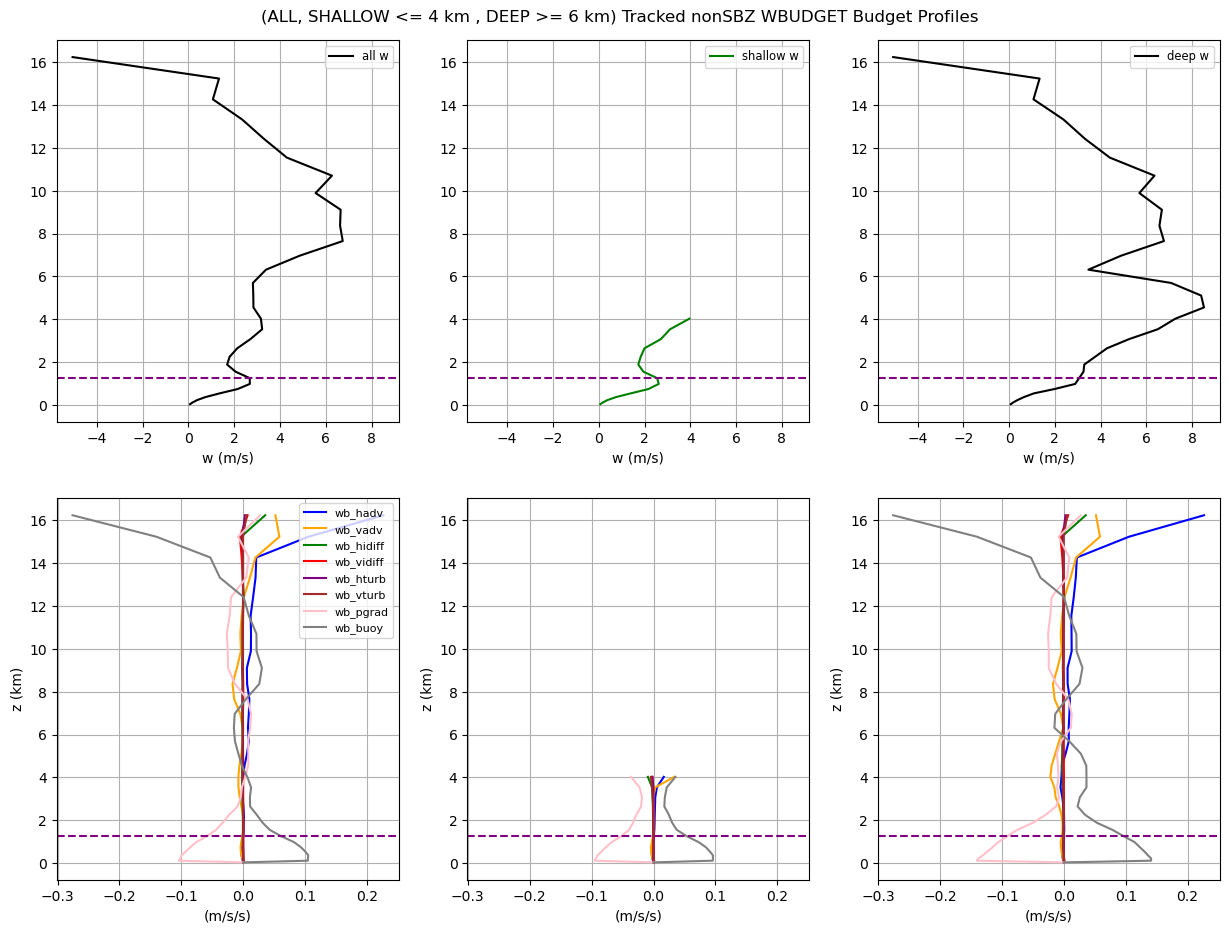

In [27]:
#nonSBZ W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked nonSBZ WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_WBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow': 
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_WBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':  
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_WBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_nonSBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')



#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonSBZ_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.7565860889394231, 15.950787789735582)
(-0.7796000954695046, 17.05360203469172)
(-0.017707170925702963, 0.021135458337084856)
(-0.7796000954695046, 17.05360203469172)


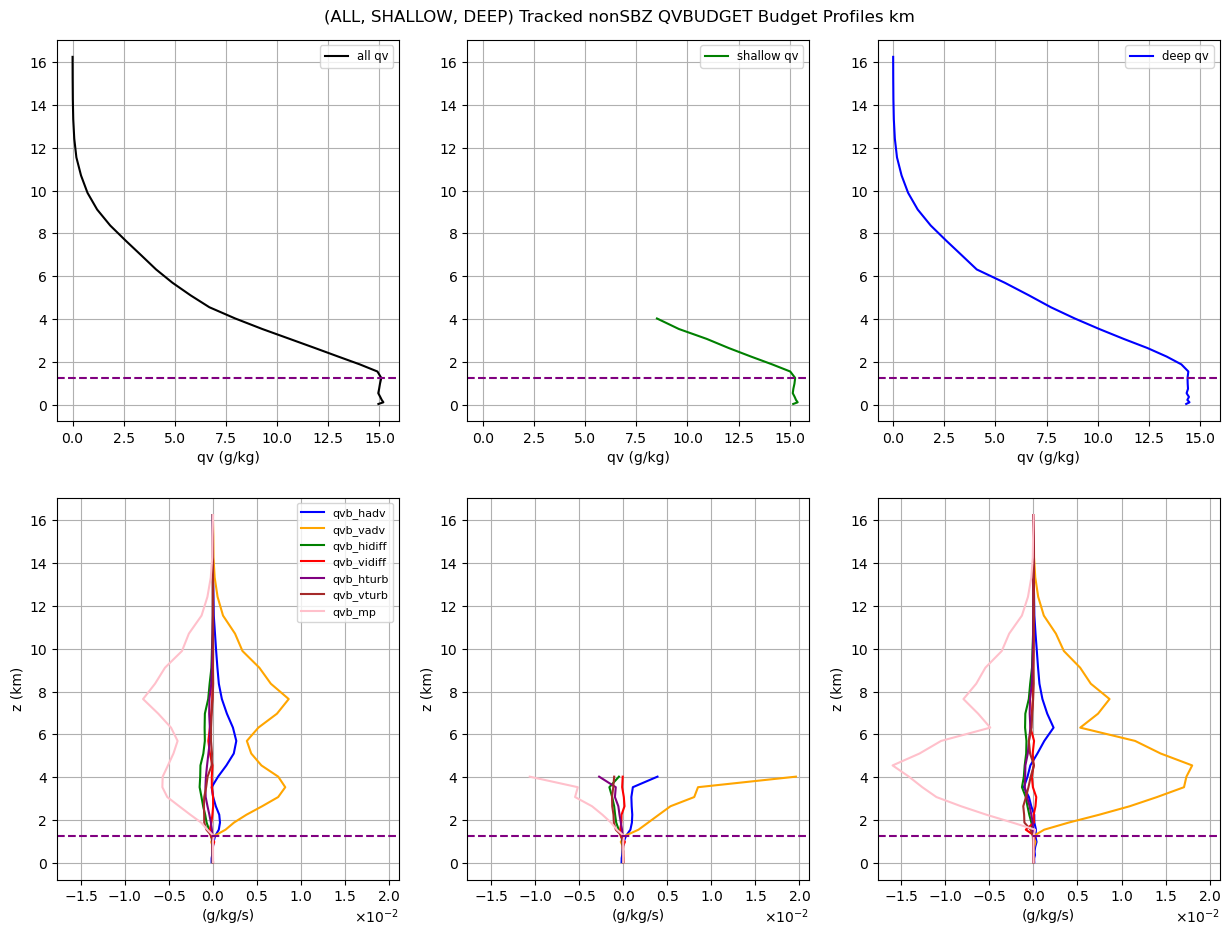

In [28]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonSBZ QVBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_QVBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_QVBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_QVBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0]*1000,out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_nonSBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonSBZ_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(302.48992641908103, 372.32123494141524)
(-0.7796000954695046, 17.05360203469172)
(-0.16787707585220538, 0.15945710704351465)
(-0.7796000954695046, 17.05360203469172)


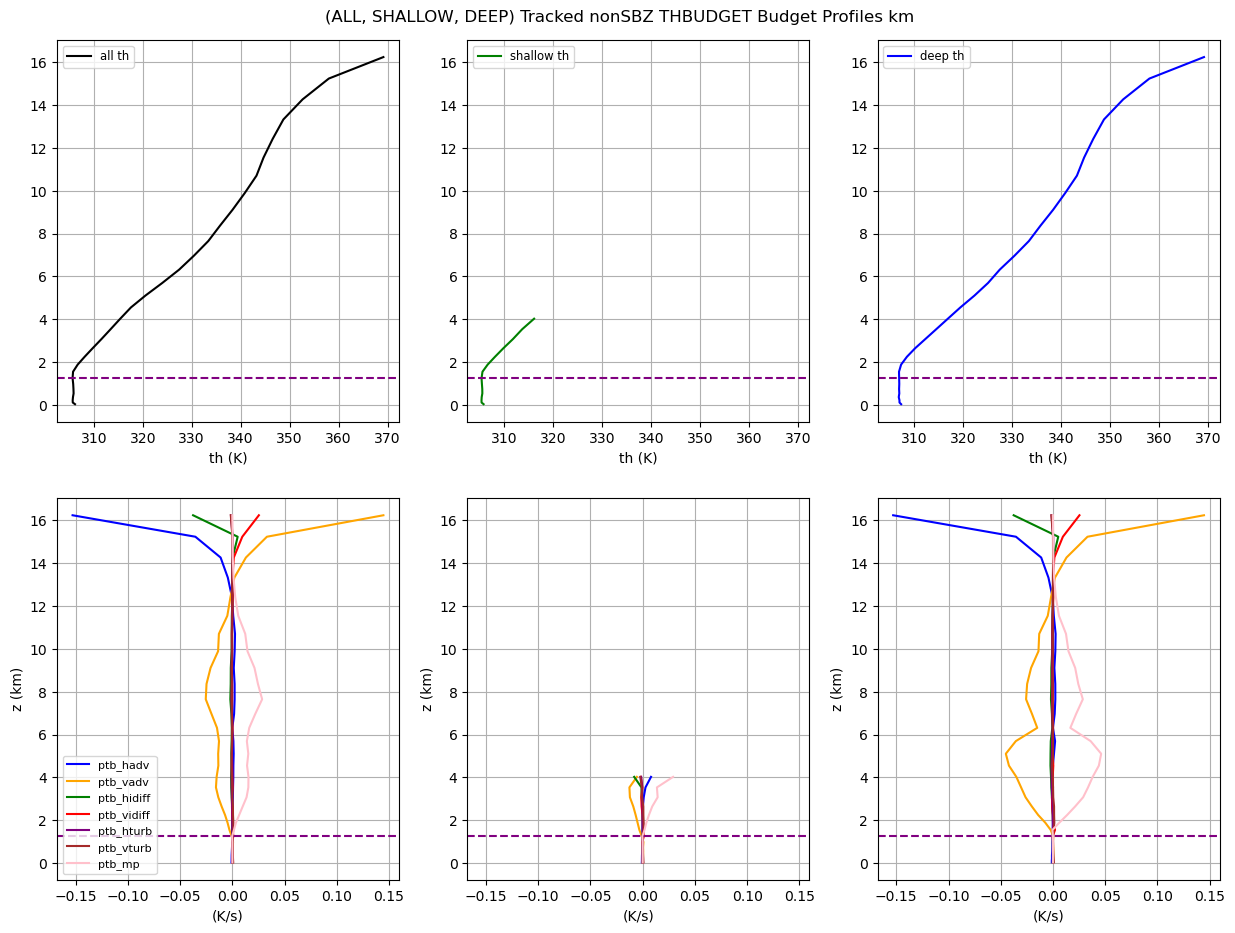

In [29]:
#TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonSBZ THBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_THBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_THBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_THBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower left', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_nonSBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonSBZ_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [ ]:
# SBZ minus nonSBZ

currently on type all
currently on type shallow
currently on type deep
(-3.7210483096283933, 2.3421068933021245)
(-0.6809093949384988, 14.981097323540599)
(-0.0725070737173883, 0.07136250272805585)
(-0.6809093949384988, 14.981097323540599)


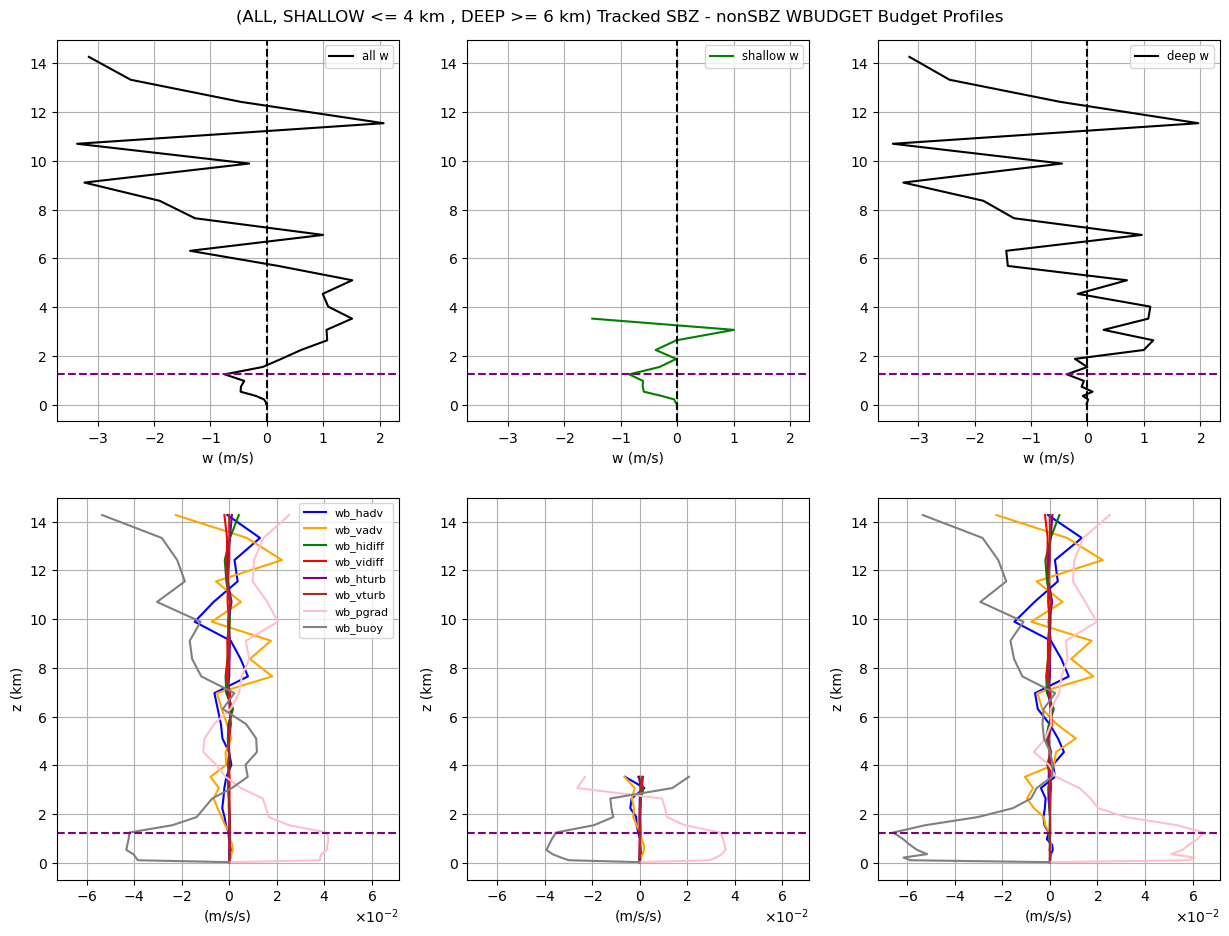

In [30]:

# SBZ minus nonSBZ W BUDGET

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked SBZ - nonSBZ WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

    if type=='all':    
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_WBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow': 
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_WBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':  
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_WBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w1 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv1 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv1 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff1 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff1 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb1 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb1 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad1 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy1 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy
    
    if type=='all':    
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_WBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow': 
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_WBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':  
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_WBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w2 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv2 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv2 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff2 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff2 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb2 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb2 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad2 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy2 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_arr), mean_LFC(ALL_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_SBZ_out_arr), mean_LFC(SHALLOW_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_SBZ_out_arr), mean_LFC(DEEP_nonSBZ_out_arr))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])


#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.0002490526353241701, 0.0016162576829360747)
(-0.6809093949384988, 14.981097323540599)
(-5.205467693171295e-06, 5.144369310985702e-06)
(-0.6809093949384988, 14.981097323540599)


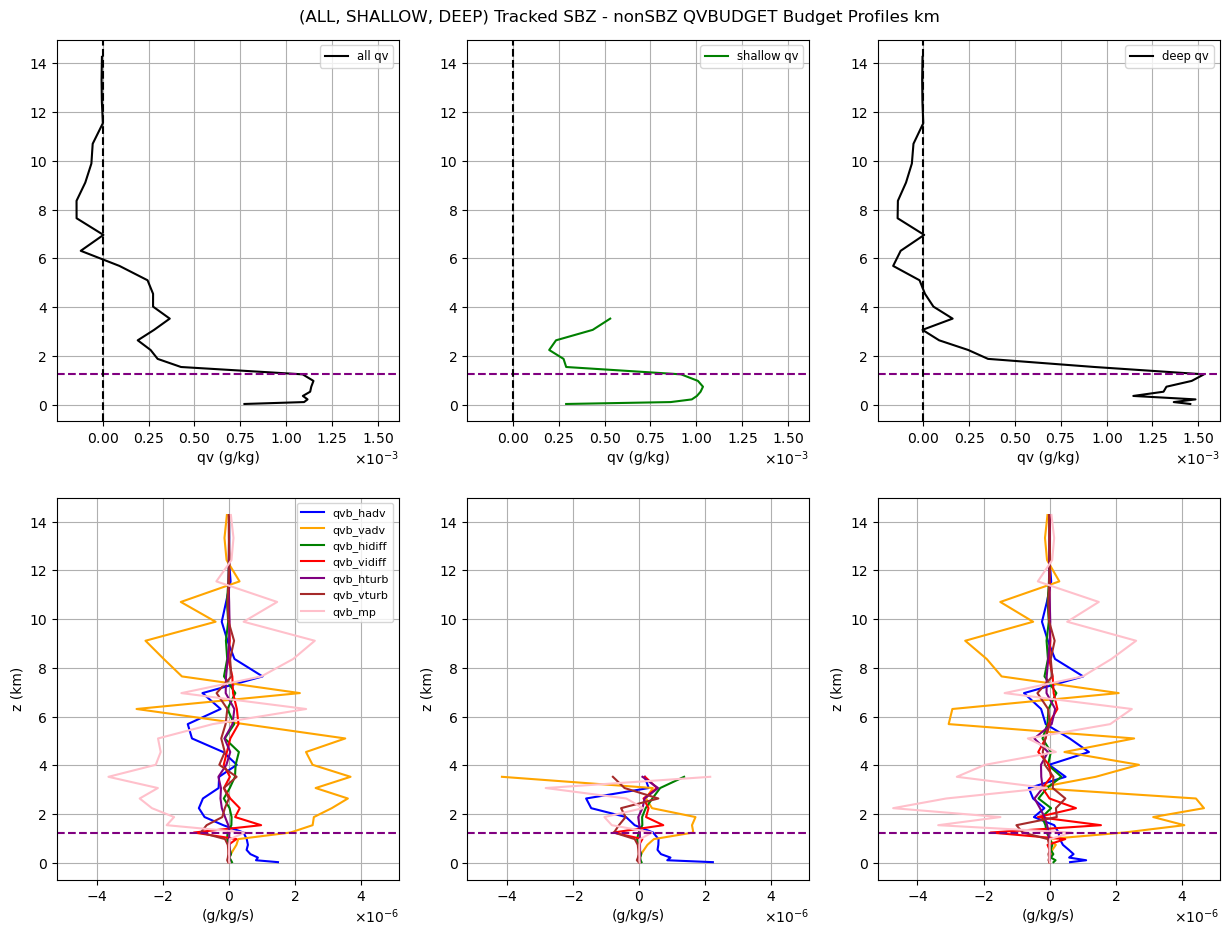

In [31]:
# SBZ minus nonSBZ QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - nonSBZ QVBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

     
    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_QVBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_QVBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_QVBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv1 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv1 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv1 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff1 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff1 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb1 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb1 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp1 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_QVBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_QVBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_QVBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv2 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv2 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv2 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff2 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff2 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb2 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb2 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp2 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_arr), mean_LFC(ALL_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_SBZ_out_arr), mean_LFC(SHALLOW_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_SBZ_out_arr), mean_LFC(DEEP_nonSBZ_out_arr))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-3.092379444429156, 0.8723813506792368)
(-0.6809093949384988, 14.981097323540599)
(-0.03449299919211626, 0.03371750111534204)
(-0.6809093949384988, 14.981097323540599)


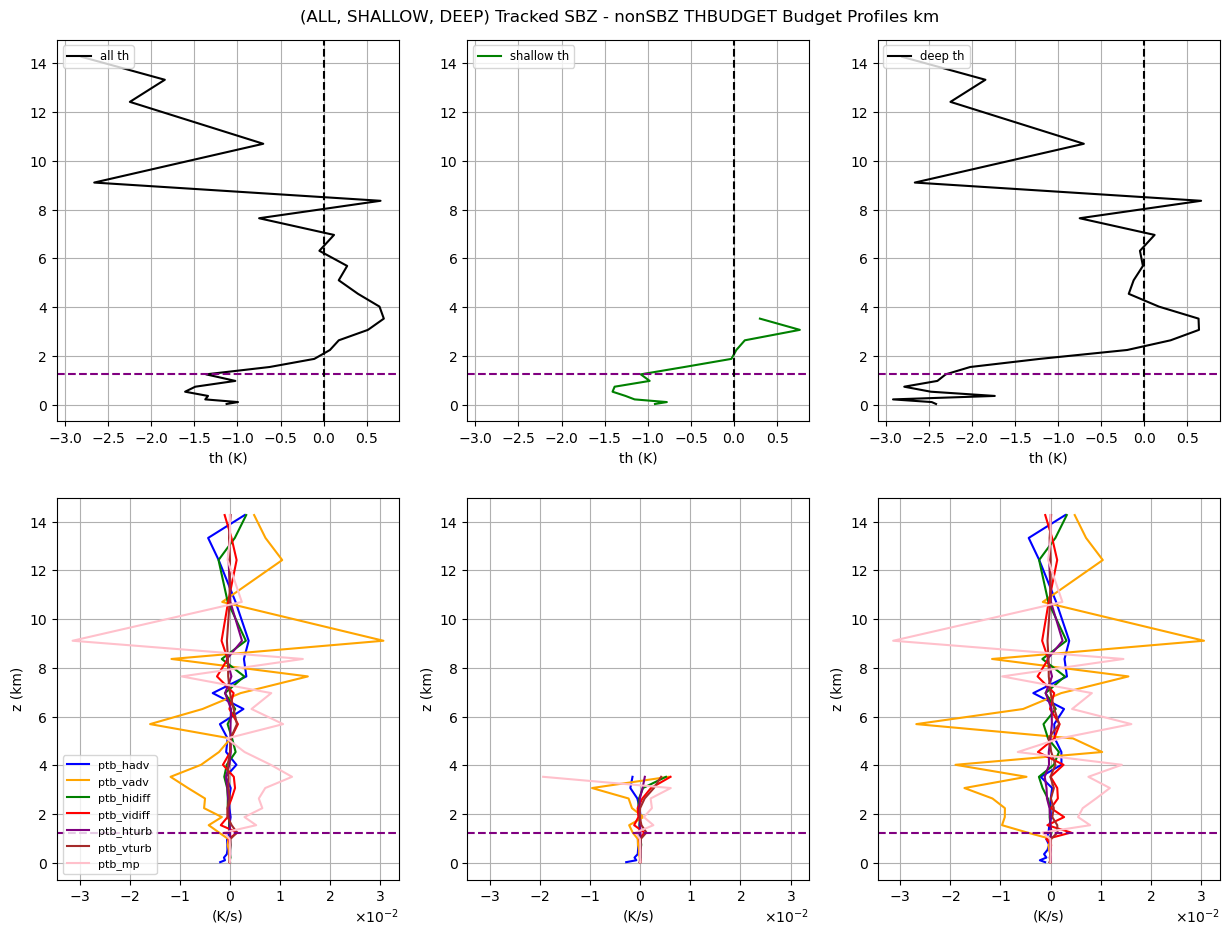

In [32]:
# SBZ minus nonSBZ TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - nonSBZ THBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')


    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_THBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_THBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_THBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th1 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv1 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv1 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff1 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff1 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb1 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb1 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp1 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient

    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_THBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_THBUDGET_profile_deep.h5'

    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th2 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv2 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv2 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff2 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff2 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb2 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb2 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp2 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower left', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_arr), mean_LFC(ALL_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_SBZ_out_arr), mean_LFC(SHALLOW_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_SBZ_out_arr), mean_LFC(DEEP_nonSBZ_out_arr))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3,ax4,ax5,ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [33]:
#ColdPool
################################################################

currently on type all
currently on type shallow
currently on type deep
(-5.74257168069052, 9.194482195237413)
(-0.7796000954695046, 17.05360203469172)
(-0.3008802050414185, 0.2515942747704685)
(-0.7796000954695046, 17.05360203469172)


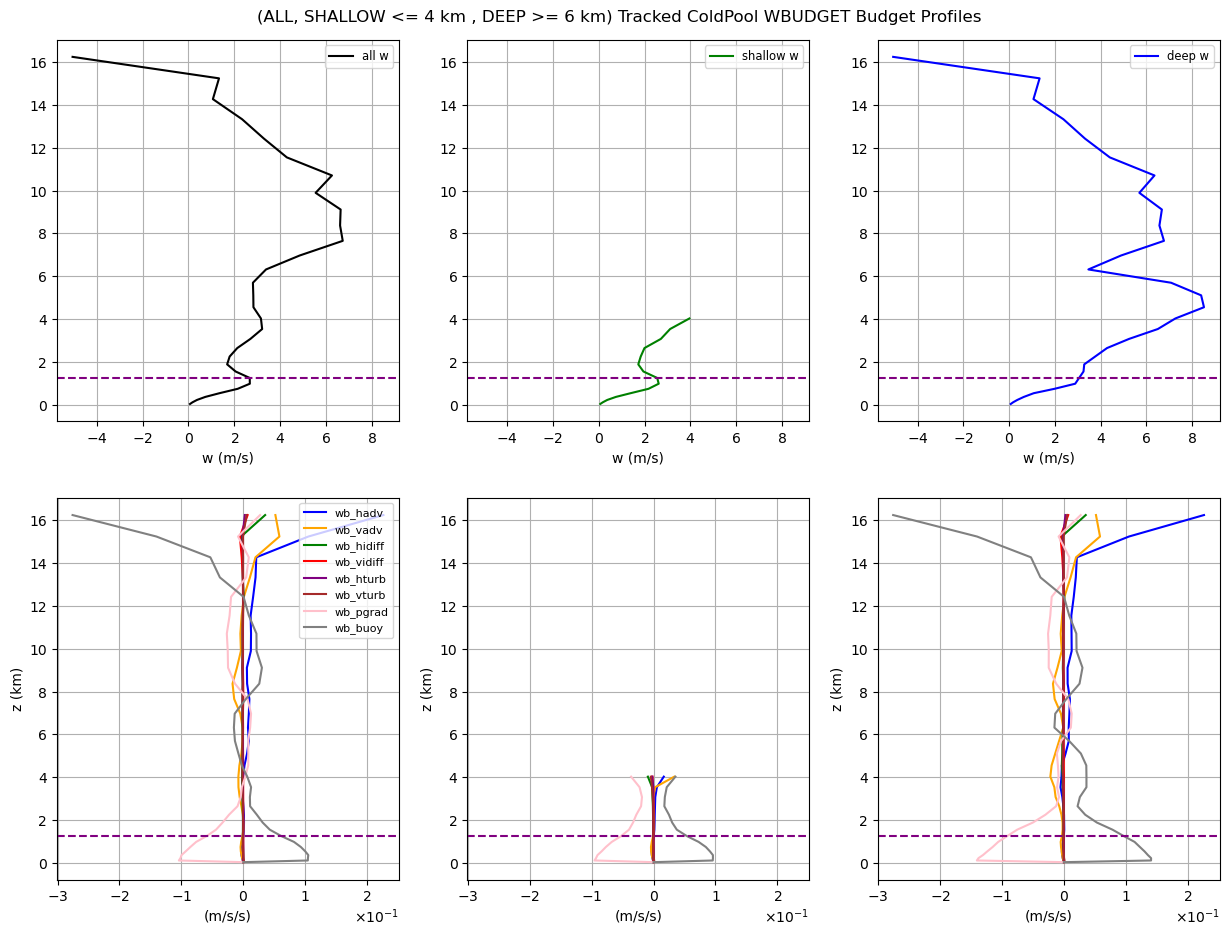

In [34]:
#ColdPool W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked ColdPool WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_all_WBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow': 
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_shallow_WBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':  
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_deep_WBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/ColdPool_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.7565860889394231, 15.950787789735582)
(-0.7796000954695046, 17.05360203469172)
(-0.017707170925702963, 0.021135458337084856)
(-0.7796000954695046, 17.05360203469172)


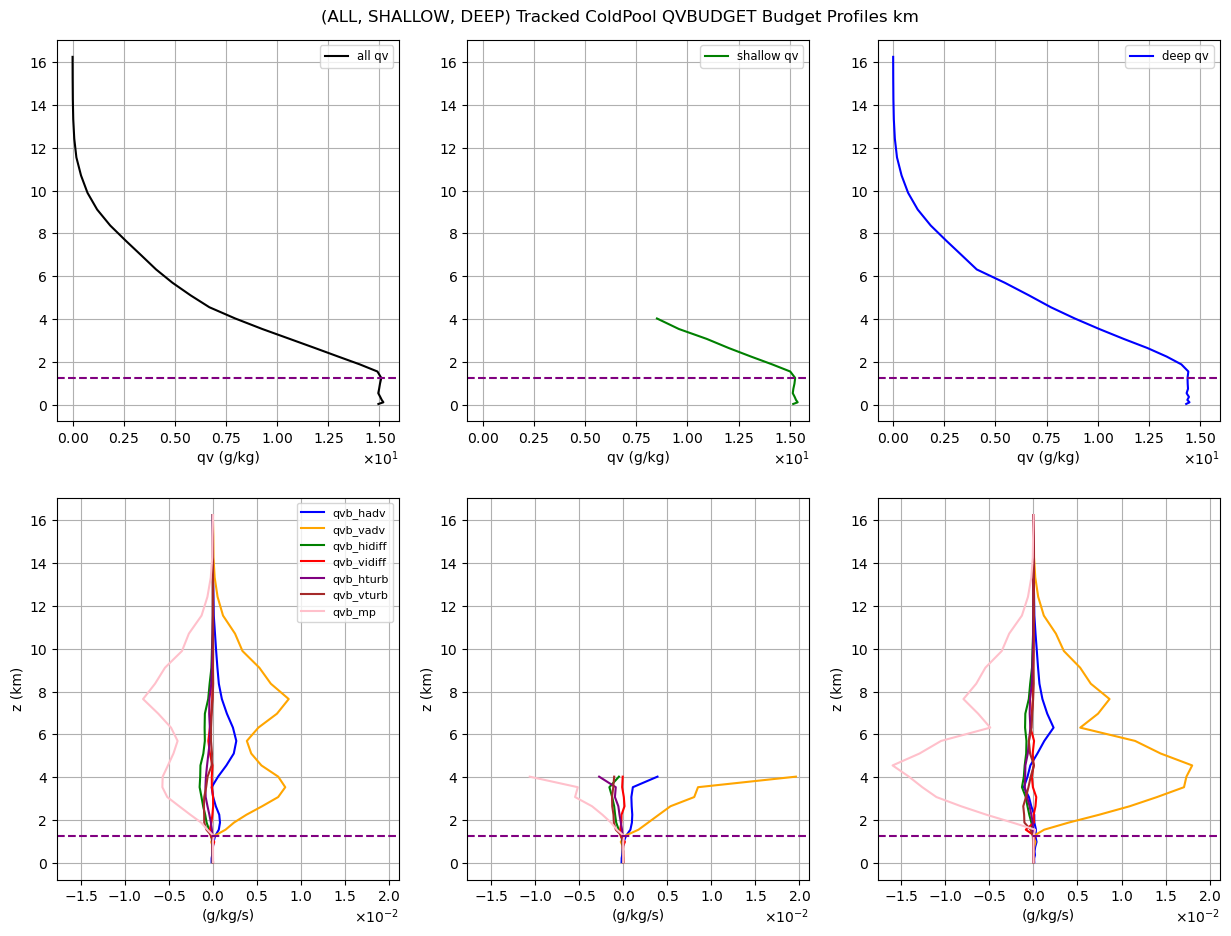

In [37]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked ColdPool QVBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_all_QVBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_shallow_QVBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_deep_QVBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0]*1000,out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])

        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/ColdPool_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(302.48992641908103, 372.32123494141524)
(-0.7796000954695046, 17.05360203469172)
(-0.16787707585220538, 0.15945710704351465)
(-0.7796000954695046, 17.05360203469172)


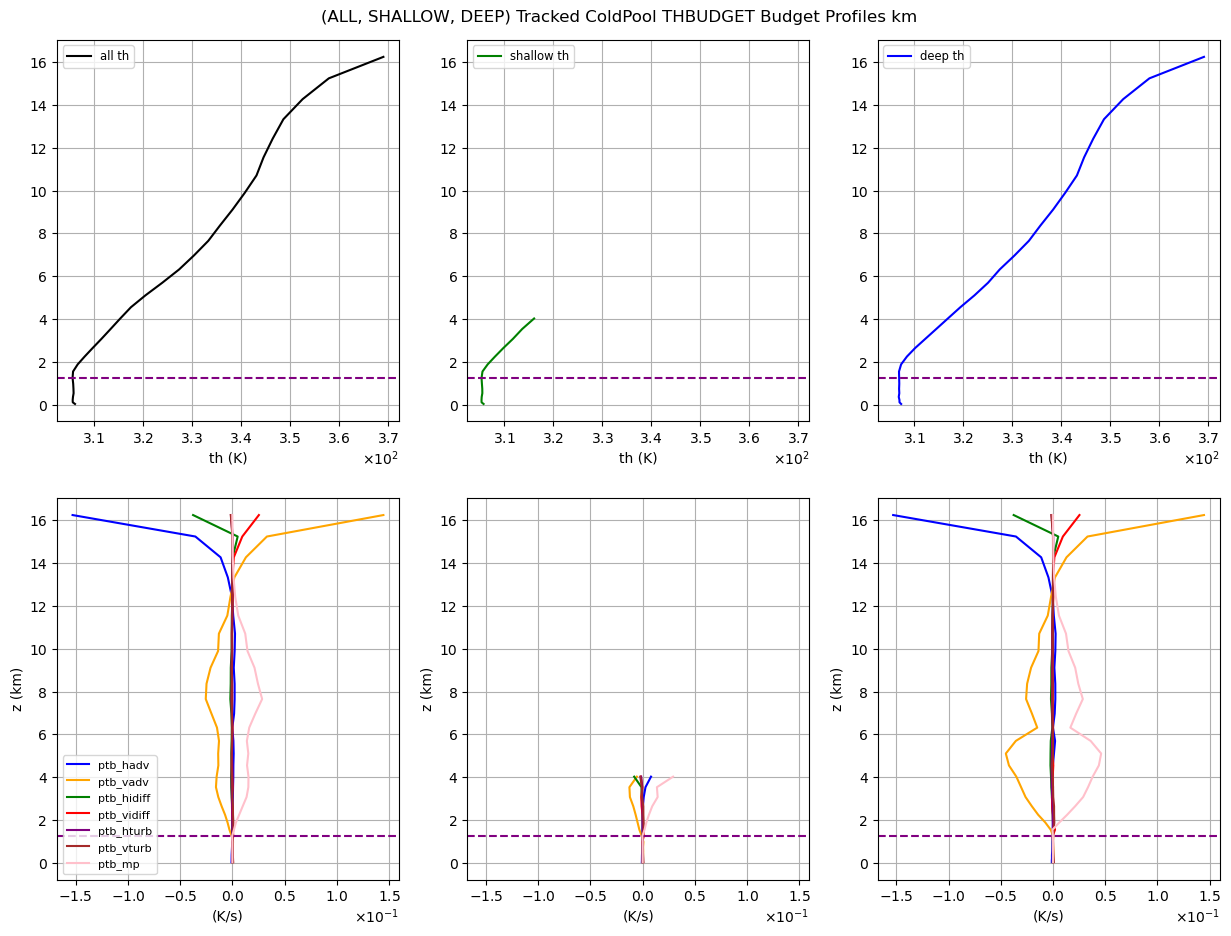

In [38]:
#TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked ColdPool THBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_all_THBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_shallow_THBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_deep_THBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
    
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower left', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/ColdPool_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [ ]:
# SBZ minus ColdPool
############################################

In [39]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

currently on type all
currently on type shallow
currently on type deep
(-3.7210483096283933, 2.3421068933021245)
(-0.6809093949384988, 14.981097323540599)
(-0.0725070737173883, 0.07136250272805585)
(-0.6809093949384988, 14.981097323540599)


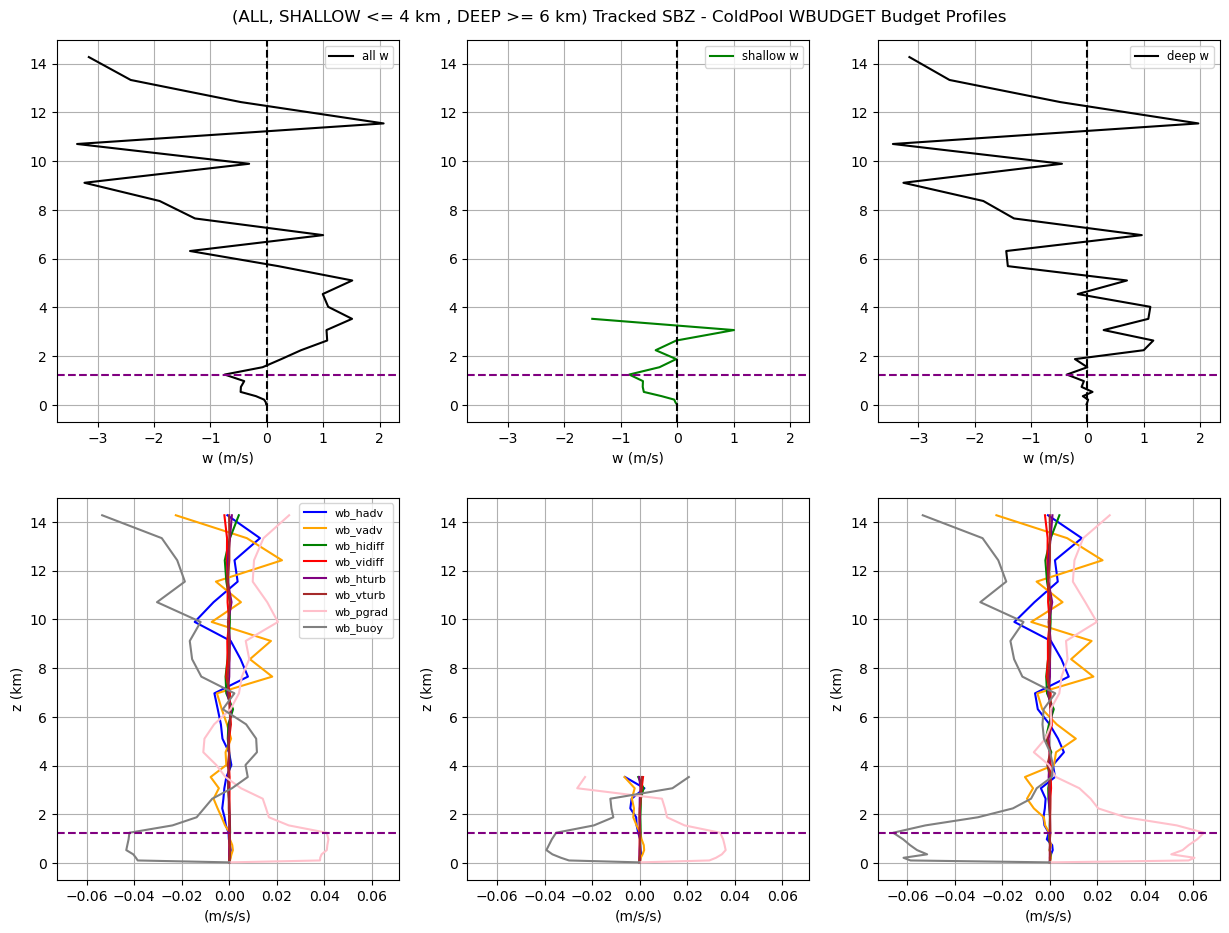

In [40]:
# SBZ minus ColdPool W BUDGET

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked SBZ - ColdPool WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

    if type=='all':    
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_WBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow': 
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_WBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':  
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_WBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w1 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv1 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv1 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff1 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff1 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb1 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb1 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad1 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy1 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy
    
    if type=='all':    
        input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_all_WBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow': 
        input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_shallow_WBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':  
        input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_deep_WBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w2 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv2 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv2 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff2 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff2 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb2 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb2 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad2 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy2 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusColdPool_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.2490526353241701, 1.6162576829360746)
(-0.6809093949384988, 14.981097323540599)
(-0.005205467693171296, 0.005144369310985703)
(-0.6809093949384988, 14.981097323540599)


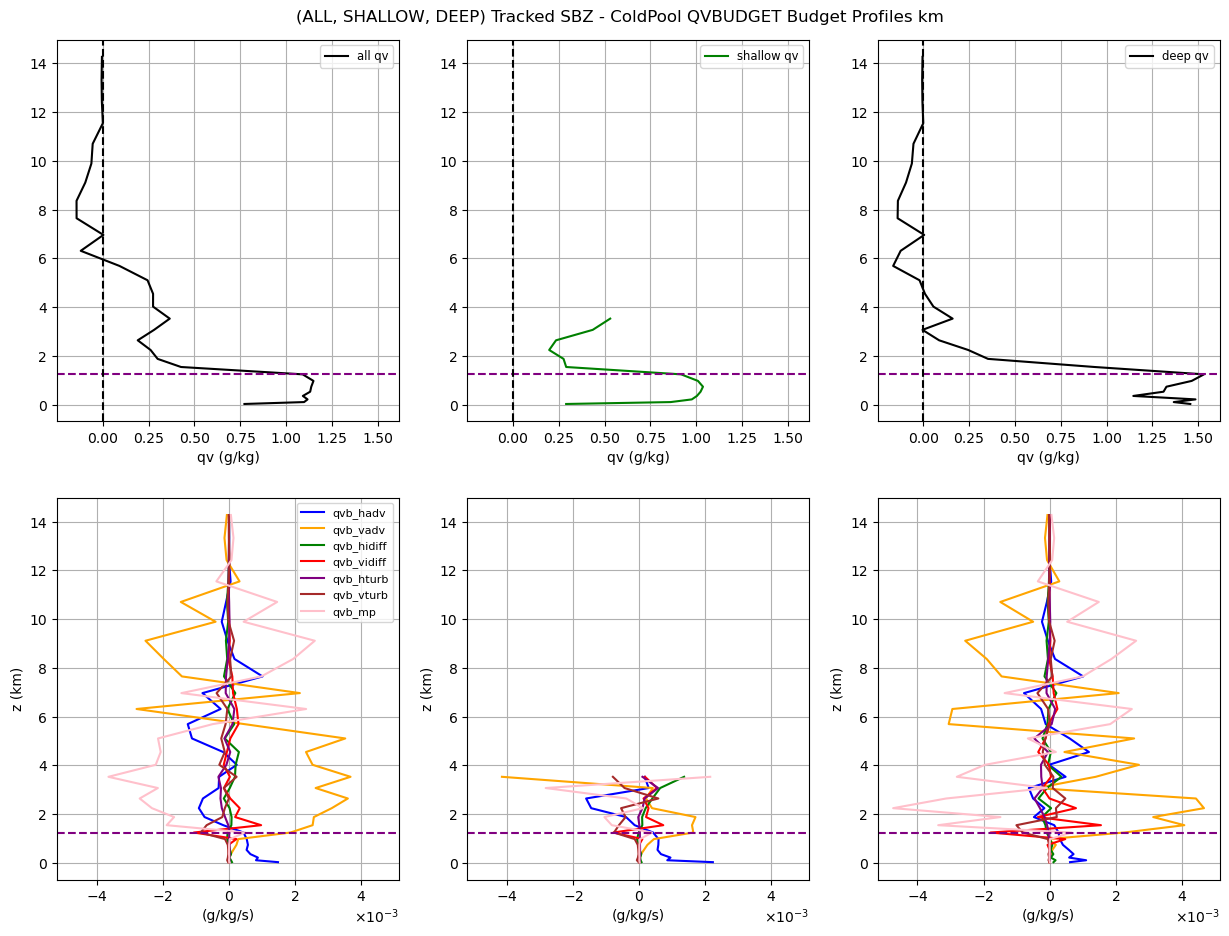

In [41]:
# SBZ minus ColdPool QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - ColdPool QVBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

     
    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_QVBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_QVBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_QVBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv1 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv1 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv1 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff1 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff1 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb1 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb1 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp1 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_all_QVBUDGET_profile_all'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_shallow_QVBUDGET_profile_shallow'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_deep_QVBUDGET_profile_deep'
            input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv2 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv2 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv2 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff2 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff2 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb2 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb2 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp2 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0]*1000,out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusColdPool_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-2.412413433973762, 0.9251423655871605)
(-0.6809093949384988, 14.981097323540599)
(-0.01156648208250538, 0.015402301206279488)
(-0.6809093949384988, 14.981097323540599)


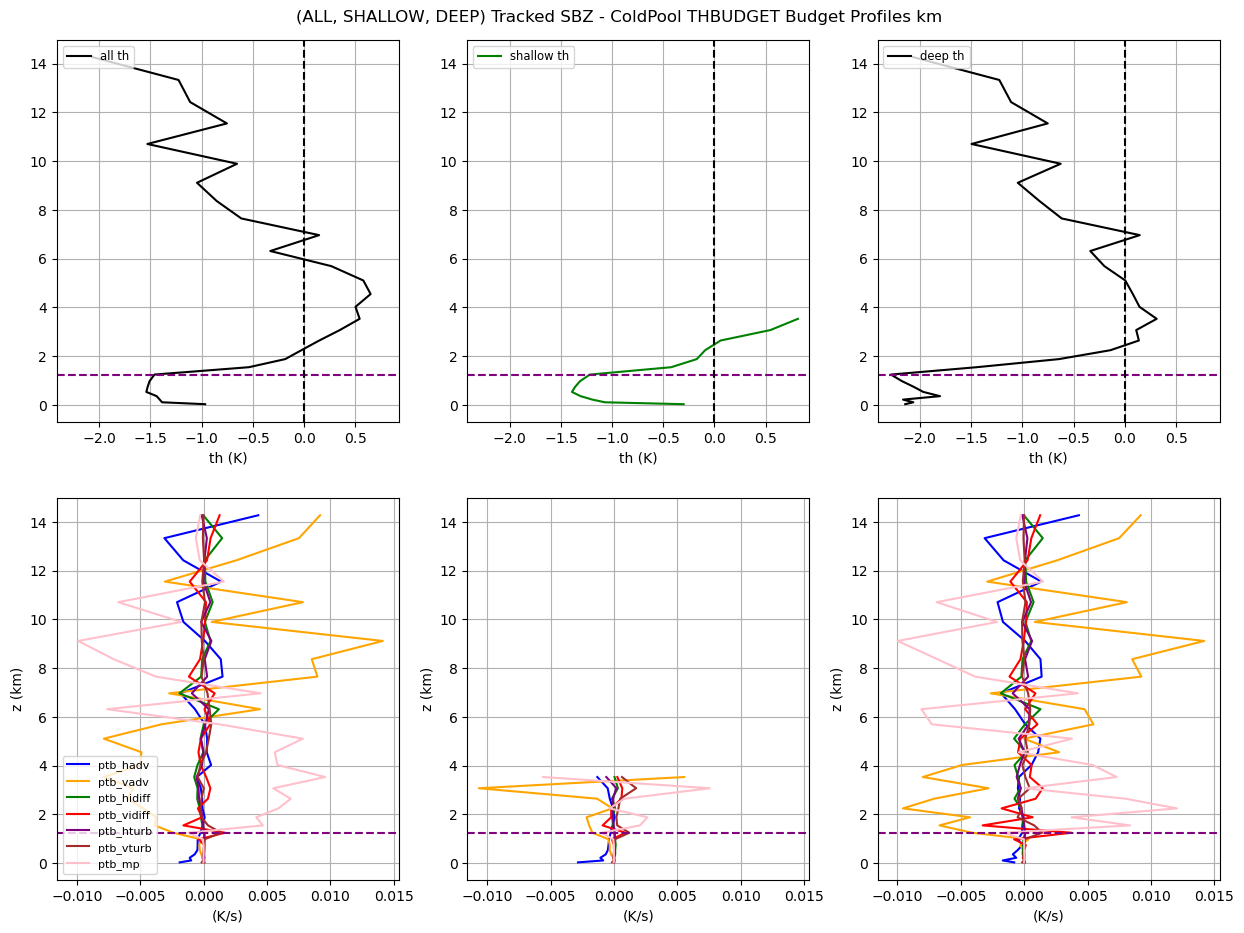

In [42]:
# SBZ minus ColdPool TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - ColdPool THBUDGET Budget Profiles km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')


    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_THBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_THBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_THBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th1 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv1 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv1 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff1 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff1 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb1 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb1 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp1 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient

    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_all_THBUDGET_profile_all'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_shallow_THBUDGET_profile_shallow'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/ColdPool_deep_THBUDGET_profile_deep'
        input_file+=f'_{res}_{t_res}_{Np_str}.h5'

    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th2 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv2 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv2 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff2 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff2 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb2 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb2 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp2 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower left', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusColdPool_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited